In [ ]:
# Libraries import karna
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

print("✅ TensorFlow version:", tf.__version__)
print("✅ All libraries imported successfully!")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

✅ TensorFlow version: 2.20.0
✅ All libraries imported successfully!
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


📥 MNIST Dataset load ho raha hai...
✅ Dataset Ready!
Training samples: 60000
Testing samples: 10000
Image size: 28x28 pixels
Classes: 0-9 digits


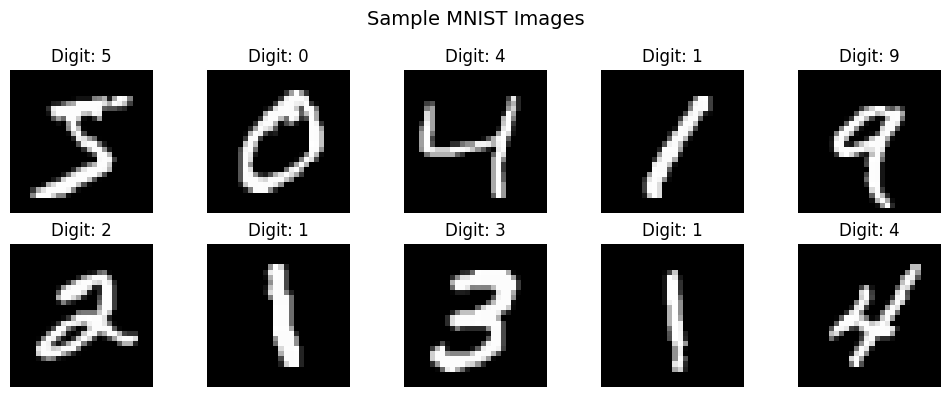

In [ ]:
# MNIST Dataset - Direct Keras se (No download needed!)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical  # ← yeh line add karo
import numpy as np
import matplotlib.pyplot as plt

print("📥 MNIST Dataset load ho raha hai...")

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize (0-255 ko 0-1 mein convert karna)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# CNN ke liye shape add karna
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Labels one-hot encode karna
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("✅ Dataset Ready!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Image size: 28x28 pixels")
print(f"Classes: 0-9 digits")

# Sample images dikhao
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f'Digit: {y_train[i]}')
    plt.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Sare imports ek saath
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

# CNN Model banana
model = Sequential([
    # Layer 1: First Convolution
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Layer 2: Second Convolution
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Layer 3: Third Convolution
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),

    # Flatten aur Dense layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Model compile karna
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n✅ CNN Model ready hai!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)


✅ CNN Model ready hai!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for smart training
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

print("Training started...")
print("=" * 40)

# Train the model
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nTraining Complete!")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Training started...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9552 - loss: 0.1451 - val_accuracy: 0.7365 - val_loss: 1.1851 - learning_rate: 0.0010
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9835 - loss: 0.0548 - val_accuracy: 0.9903 - val_loss: 0.0396 - learning_rate: 0.0010
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9886 - loss: 0.0386 - val_accuracy: 0.9812 - val_loss: 0.0686 - learning_rate: 0.0010
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9902 - loss: 0.0299 - val_accuracy: 0.9887 - val_loss: 0.0433 - learning_rate: 0.0010
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9944 - loss: 0.0181 - val_accuracy: 0.9925 - val_loss: 0.0292 - learning_rate: 5.0000e-04
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9971 - loss: 0.0094 - val_accuracy: 0.9923 - val_loss: 0.0295 - learning_rate: 5.0000e-04
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accu

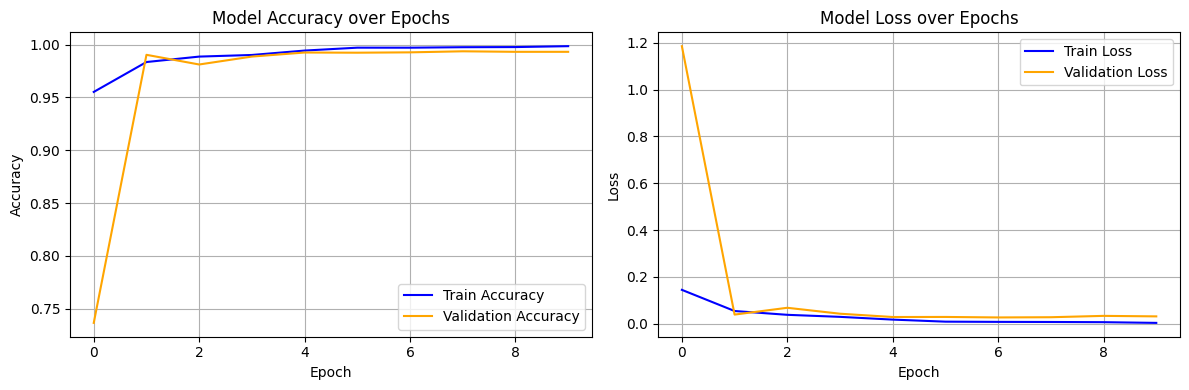


Final Test Accuracy: 99.10%
Final Test Loss: 0.0323


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Training history plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Final evaluation on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nFinal Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


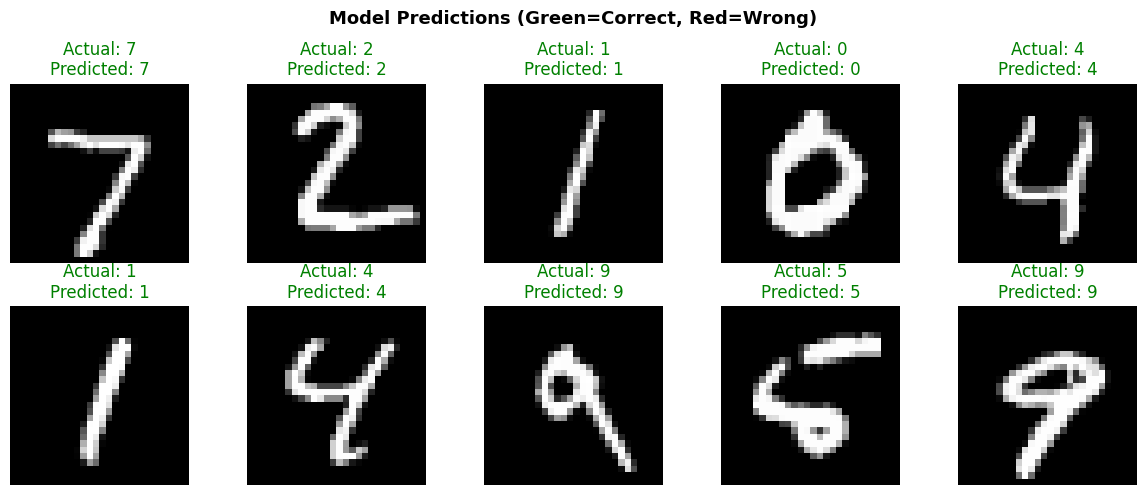

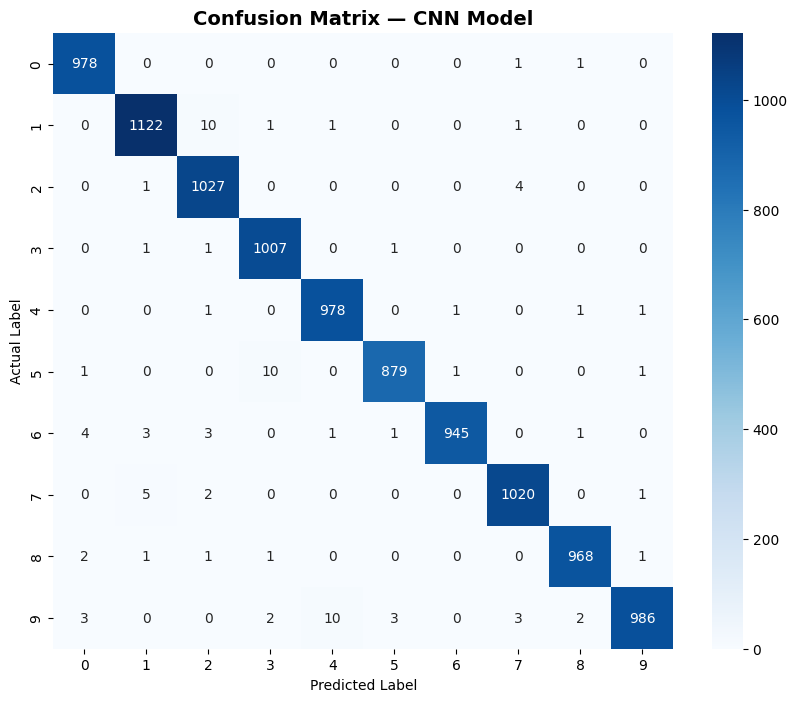

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [7]:
# Make predictions on test data
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Show sample predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    actual = y_test[i]
    predicted = predicted_labels[i]
    color = 'green' if actual == predicted else 'red'
    axes[i].set_title(f'Actual: {actual}\nPredicted: {predicted}', color=color)
    axes[i].axis('off')

plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — CNN Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

print(classification_report(y_test, predicted_labels))

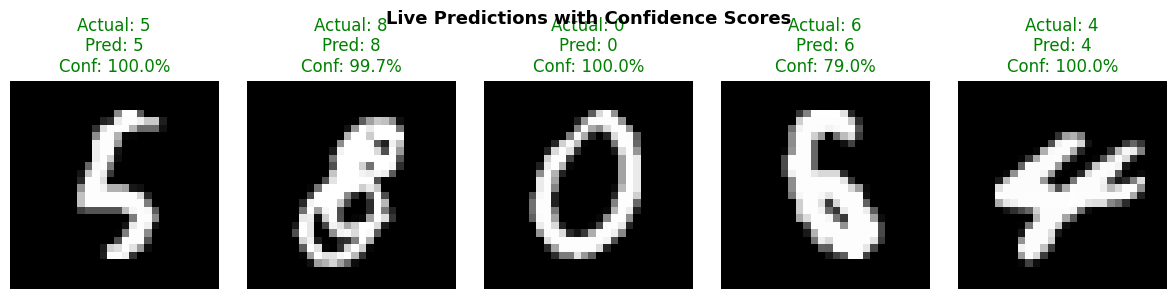

Project Complete!
Final Model Accuracy: 99.10%
Total Parameters: 391,306


In [8]:
# Live prediction on random test images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

random_indices = np.random.randint(0, len(X_test), 5)

for i, idx in enumerate(random_indices):
    img = X_test[idx]
    actual = y_test[idx]

    pred = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
    predicted = np.argmax(pred)
    confidence = np.max(pred) * 100

    axes[i].imshow(img.reshape(28, 28), cmap='gray')
    color = 'green' if actual == predicted else 'red'
    axes[i].set_title(f'Actual: {actual}\nPred: {predicted}\nConf: {confidence:.1f}%', color=color)
    axes[i].axis('off')

plt.suptitle('Live Predictions with Confidence Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Project Complete!")
print(f"Final Model Accuracy: 99.10%")
print(f"Total Parameters: {model.count_params():,}")